# Emotion-Aware Chatbot, Step 1: can body sensors tell us valence and arousal?

**Approach:** `kemocon_physio_ml` · **Dataset:** K-EmoCon · **Author:** Mudasir · September 2026

> **In one sentence:** from wearable sensors we can estimate a person's **arousal** (calm ↔ activated) reasonably well, *if* they spend 3 minutes calibrating at the start of the chat. **Valence** (pleasant ↔ unpleasant) cannot be recovered from body signals in this data.

| | Arousal | Valence |
|---|---|---|
| New person, no calibration | ✗ same as guessing (35% vs 33%) | ✗ worse than guessing |
| With 3-min calibration | ✓ **60% accuracy** (3 classes, chance 33%), **69%** on the confident 28% of windows | ✗ no better than the calibration ratings alone |
| Abstain-when-unsure | ✓ confidence ranks windows correctly | ✗ confidence is meaningless |

**Contents**
1. The problem we are solving
2. The dataset (K-EmoCon)
3. From continuous sensor signals to a table of rows
4. What the data says *before* any model
5. Modelling: candidates, protocol, why
6. Results
7. Why published papers report 90%+ on the same data
8. Conclusions and next direction
9. How to reproduce

## 0. Setup

In [1]:
import sys, json, os
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

APPROACH = Path.cwd().parent                      # notebooks/ -> approach folder
sys.path.insert(0, str(APPROACH / "src"))
import config
from config import ALL_FEATURES, FEATURE_GROUPS, FEATURE_SETS, features_of

FIG = APPROACH / "reports" / "figures"
RES = json.load(open(APPROACH / "reports" / "results.json"))
HAVE_DATA = (config.PROCESSED / "dataset.csv").exists()
print("K-EmoCon data available locally:", HAVE_DATA)

def show(name, width=900):
    # charts are re-encoded as small palette PNGs so the notebook stays light enough for GitHub to render
    import io
    from PIL import Image as PILImage
    im = PILImage.open(FIG / name).convert("RGB")
    if im.width > 1200:
        im = im.resize((1200, round(im.height * 1200 / im.width)), PILImage.LANCZOS)
    buf = io.BytesIO()
    im.quantize(colors=256, method=PILImage.Quantize.FASTOCTREE).save(buf, "PNG", optimize=True)
    display(Image(data=buf.getvalue(), width=width))

pd.set_option("display.precision", 3)
plt.rcParams.update({"figure.dpi": 80, "axes.grid": True, "grid.alpha": 0.3})

K-EmoCon data available locally: True


## 1. The problem we are solving

In the lab, a person talks to an LLM chatbot while wearing body sensors. We want the chatbot to **know how the person feels** and adapt to it. We do **not** want to paste raw sensor numbers into the LLM: it can't interpret them reliably and they would flood its context. Instead:

```
body sensors ──► emotion model ──► valence + arousal + confidence ─┐
                                                                    ├──► short emotional-state summary ──► chatbot memory
conversation ──► compressed summary ───────────────────────────────┘
```

- **Valence** = how pleasant the feeling is (negative ↔ positive).
- **Arousal** = how activated the body is (calm/sleepy ↔ excited/agitated).

Together they place any emotion on Russell's circumplex: e.g. *stressed* = low valence + high arousal, *relaxed* = high valence + low arousal.

**Hard requirement:** the model must say *"unknown"* when it is not confident. A wrong emotional label could make the chatbot respond inappropriately, so no answer is better than a wrong one.

**Step 1 (this notebook):** build a dataset, train such a model, and test honestly whether it works on people it has never seen.

## 2. The dataset: K-EmoCon

[K-EmoCon](https://doi.org/10.5281/zenodo.3931963) (Park et al., *Scientific Data* 2020) is the only public dataset where people wear body sensors during a **natural conversation**, which is closest to our chatbot scenario. 32 people (16 pairs) held ~10-minute debates on a social issue.

| Device | Worn on | Signals | Rate |
|---|---|---|---|
| Empatica **E4** | wrist | EDA (skin conductance = sweat), BVP (pulse wave), HR, IBI (beat-to-beat intervals), skin temperature, 3-axis movement | 4 Hz, 64 Hz, 1 Hz, per beat, 4 Hz, 32 Hz |
| **Polar H7** | chest | heart rate | 1 Hz |
| **NeuroSky** MindWave | forehead (1 EEG channel) | 8 brain-wave band powers, "Attention", "Meditation" | ~1 Hz |

**Labels:** after the debate each person re-watched their video. It paused **every 5 seconds** and they rated their **arousal** and **valence** on a 1–5 scale. We use these **self-ratings**, because the chatbot should respond to what the person *felt*, not to how they looked to others.

All sensors record **continuously**. There is one label per 5-second clip.

In [2]:
if HAVE_DATA:
    subj = pd.read_csv(config.RAW / "metadata" / "subjects.csv")
    avail = pd.read_csv(config.RAW / "metadata" / "data_availability.csv").set_index("pid")
    subj["debate_min"] = (subj.endTime - subj.startTime) / 60000
    subj["pre_debate_min"] = (subj.startTime - subj.initTime) / 60000
    display(subj[["debate_min", "pre_debate_min"]].describe().loc[["mean", "min", "max"]].round(1))
    cols = ["E4_EDA", "E4_BVP", "E4_HR", "E4_IBI", "E4_TEMP", "E4_ACC", "Polar_HR", "BrainWave", "Attention", "Meditation", "self_annotations"]
    display(avail[cols].sum().rename("people with this signal (of 32)").to_frame().T)

,debate_min,pre_debate_min
mean,10.8,9.6
min,10.1,4.3
max,14.2,18.1


,E4_EDA,E4_BVP,E4_HR,E4_IBI,E4_TEMP,E4_ACC,Polar_HR,BrainWave,Attention,Meditation,self_annotations
people with this signal (of 32),28,28,28,27,28,28,25,32,30,30,32


## 3. From continuous sensor signals to a table of rows

The model needs a **table**: one row per example, sensor columns, and a label at the end. Every sensor streams continuously, but labels exist only per 5-second clip, so:

**1 row = 1 five-second window of one person** → summarise every sensor's samples in that window → attach that clip's rating.

A 10-minute debate gives ~120 rows per person. Below are the raw signals of one participant for the first minute of the debate. The dotted lines are the 5-second windows, and the bottom panel shows their ratings.

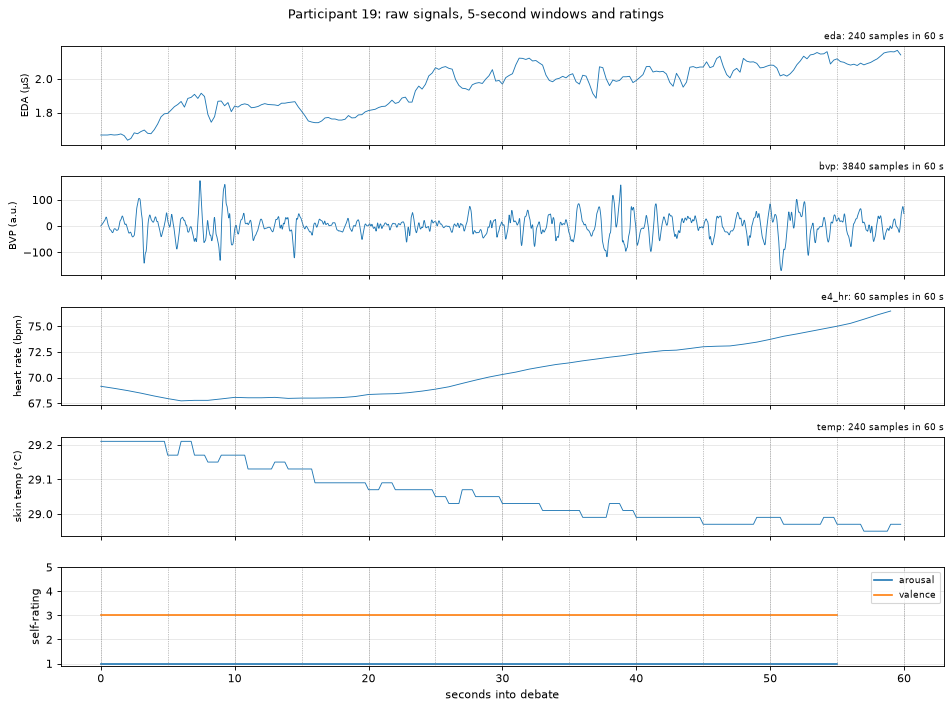

In [3]:
if HAVE_DATA:
    from build_dataset import load_signals, load_labels
    PID = 19
    m = subj.set_index("pid").loc[PID]
    sig, lab = load_signals(PID), load_labels(PID)
    t0, t1 = m.startTime, m.startTime + 60_000
    panels = [("eda", "EDA (µS)"), ("bvp", "BVP (a.u.)"), ("e4_hr", "heart rate (bpm)"), ("temp", "skin temp (°C)")]
    fig, ax = plt.subplots(len(panels) + 1, 1, figsize=(12, 9), sharex=True)
    for a, (k, name) in zip(ax, panels):
        ts, v = sig[k]; sel = (ts >= t0) & (ts < t1)
        a.plot((ts[sel] - t0) / 1000, v[sel], lw=0.8); a.set_ylabel(name, fontsize=9)
        a.set_title(f"{k}: {sel.sum()} samples in 60 s", fontsize=8, loc="right")
    l = lab[lab.seconds <= 60]
    ax[-1].step(l.seconds - 5, l.arousal, where="post", label="arousal"); ax[-1].step(l.seconds - 5, l.valence, where="post", label="valence")
    ax[-1].set_ylabel("self-rating"); ax[-1].set_yticks(range(1, 6)); ax[-1].legend(fontsize=8); ax[-1].set_xlabel("seconds into debate")
    for a in ax:
        for x in range(0, 61, 5): a.axvline(x, color="grey", ls=":", lw=0.6)
    fig.suptitle(f"Participant {PID}: raw signals, 5-second windows and ratings"); fig.tight_layout(); plt.show()

### What goes into one row

For each window we compute a few numbers per sensor. The cell below computes one real row, for the window 5–10 s into the debate.

**Why summarise instead of taking the value at the instant of the label?**
1. The label describes the **whole 5 s**, not an instant.
2. A single raw sample means nothing. One BVP value is just a point on a pulse wave.
3. The body reacts with a 1–3 s lag.
4. The sensors tick at different rates, so there is no common instant.
5. A summary of 20–320 samples is far less noisy than one sample.

Slow signals (EDA, heart-rate variability) are also summarised over the **last 30 s** (`*_30s` columns). Only past data is used, so everything works in real time.

In [4]:
if HAVE_DATA:
    from features import window_features
    f = window_features(sig, m.startTime + 5_000, m.startTime + 10_000)
    group_of = {c: g for g, cols in FEATURE_GROUPS.items() for c in cols}
    row = pd.DataFrame({"group": [group_of[c] for c in ALL_FEATURES], "value": [f[c] for c in ALL_FEATURES]}, index=ALL_FEATURES)
    display(row.T.iloc[:, :20]); display(row.T.iloc[:, 20:])
    print("label for this window: arousal =", int(lab.loc[lab.seconds == 10, "arousal"].iloc[0]),
          "| valence =", int(lab.loc[lab.seconds == 10, "valence"].iloc[0]))

,eda_mean,eda_std,eda_min,eda_max,eda_slope,eda_scr_count,eda_scr_amp,bvp_p2p,e4_hr_mean,e4_hr_std,e4_hr_slope,ibi_mean,ibi_sdnn,ibi_rmssd,ibi_count,temp_mean,temp_slope,acc_mag_mean,acc_mag_std,polar_hr_mean
group,A_eda_stats,A_eda_stats,A_eda_stats,A_eda_stats,A_eda_stats,B_eda_scr,B_eda_scr,C_bvp,D_e4_hr,D_e4_hr,D_e4_hr,E_ibi_hrv,E_ibi_hrv,E_ibi_hrv,E_ibi_hrv,F_temp,F_temp,G_acc,G_acc,H_polar_hr
value,1.846,0.046,1.743,1.915,-0.002,2.0,0.069,210.047,67.832,0.087,-0.001,NaN,NaN,NaN,0.0,29.174,-0.006,1.017,0.18,79.143


,polar_hr_std,polar_hr_slope,eeg_delta,eeg_theta,eeg_lowAlpha,eeg_highAlpha,eeg_lowBeta,eeg_highBeta,eeg_lowGamma,eeg_midGamma,eeg_alpha_beta_ratio,eeg_theta_beta_ratio,attention_mean,meditation_mean,eda_mean_30s,eda_slope_30s,eda_scr_count_30s,e4_hr_mean_30s,ibi_sdnn_30s,ibi_rmssd_30s
group,H_polar_hr,H_polar_hr,I_eeg_bands,I_eeg_bands,I_eeg_bands,I_eeg_bands,I_eeg_bands,I_eeg_bands,I_eeg_bands,I_eeg_bands,J_eeg_ratios,J_eeg_ratios,K_esense,K_esense,L_context30s,L_context30s,L_context30s,L_context30s,L_context30s,L_context30s
value,1.457,1.002,4.474,5.143,4.643,4.4,4.364,3.98,4.122,5.807,0.366,0.607,45.2,67.0,1.683,0.006,8.0,71.005,NaN,NaN


label for this window: arousal = 1 | valence = 3


### The final dataset

Full column-by-column documentation is in [`docs/DATASET.md`](../docs/DATASET.md). Construction rules:
- Windows are kept only if the wristband had skin contact (≥50% valid EDA samples).
- The **3 minutes before the debate** serve as each person's personal baseline. This includes a 2-minute relaxing video that participants watched.
- The **train/test split is by debate pair**, so no person (or their debate partner) appears in both.

In [5]:
summ = json.load(open(config.PROCESSED / "dataset_summary.json")) if HAVE_DATA else None
if HAVE_DATA:
    print(f"rows: {summ['rows']}  |  columns: {summ['columns']}  |  sensor features: {summ['features']}  |  people: {summ['participants']}")
    print(f"train rows: {summ['train_rows']}  |  test rows: {summ['test_rows']}")
    log = pd.DataFrame(summ["per_participant"]).set_index("pid").fillna(0).astype(int)
    display(log.T)
    split = json.load(open(config.PROCESSED / "split.json"))
    print("train people:", split["train_pids"]); print("test people: ", split["test_pids"], "(debate pairs", split["test_pairs"], ")")

rows: 3223  |  columns: 68  |  sensor features: 40  |  people: 26
train rows: 2476  |  test rows: 747


pid,1,2,3,4,5,6,7,8,9,10,...,23,24,25,26,27,28,29,30,31,32
labelled_windows,181,180,136,136,124,123,123,120,122,120,...,126,126,147,146,121,121,121,121,128,129
kept,170,0,0,136,124,0,0,120,122,120,...,121,121,124,124,121,121,121,121,128,129
dropped_beyond_end,10,0,0,0,0,0,0,0,0,0,...,4,4,22,21,0,0,0,0,0,0
dropped_no_eda,1,0,0,0,0,0,0,0,0,0,...,1,1,1,1,0,0,0,0,0,0
dropped_no_e4,0,180,136,0,0,123,123,0,0,0,...,0,0,0,0,0,0,0,0,0,0


train people: [1, 4, 5, 8, 11, 12, 13, 14, 15, 16, 18, 19, 21, 22, 23, 24, 27, 28, 29, 30]
test people:  [9, 10, 25, 26, 31, 32] (debate pairs [5, 13, 16] )


## 4. What the data says *before* any model

### 4.1 Labels are imbalanced
Valence is mostly "3 = neutral". We group ratings into **3 classes: low (1–2), neutral (3), high (4–5)**. 5 levels would be too fine for ~3k rows, and class probabilities give us a natural confidence score.

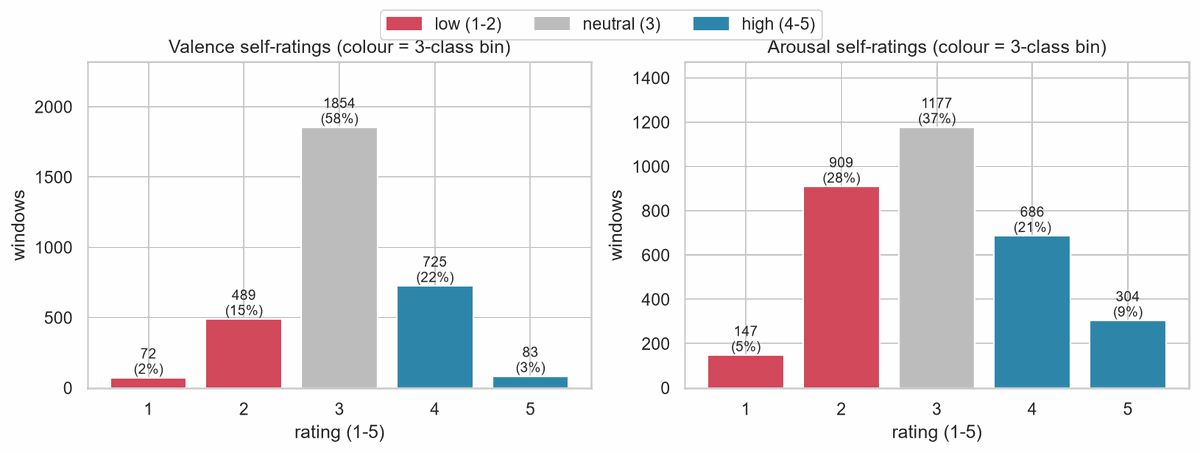

In [6]:
show("data_label_distribution.png")

### 4.2 The key finding: ratings depend mostly on *who* is rating

Each bar is one person. Some people rated almost everything "low arousal", others almost everything "high". This is **rating style**, not physiology. A model meeting a new person cannot know their style, and this turns out to be the central difficulty.

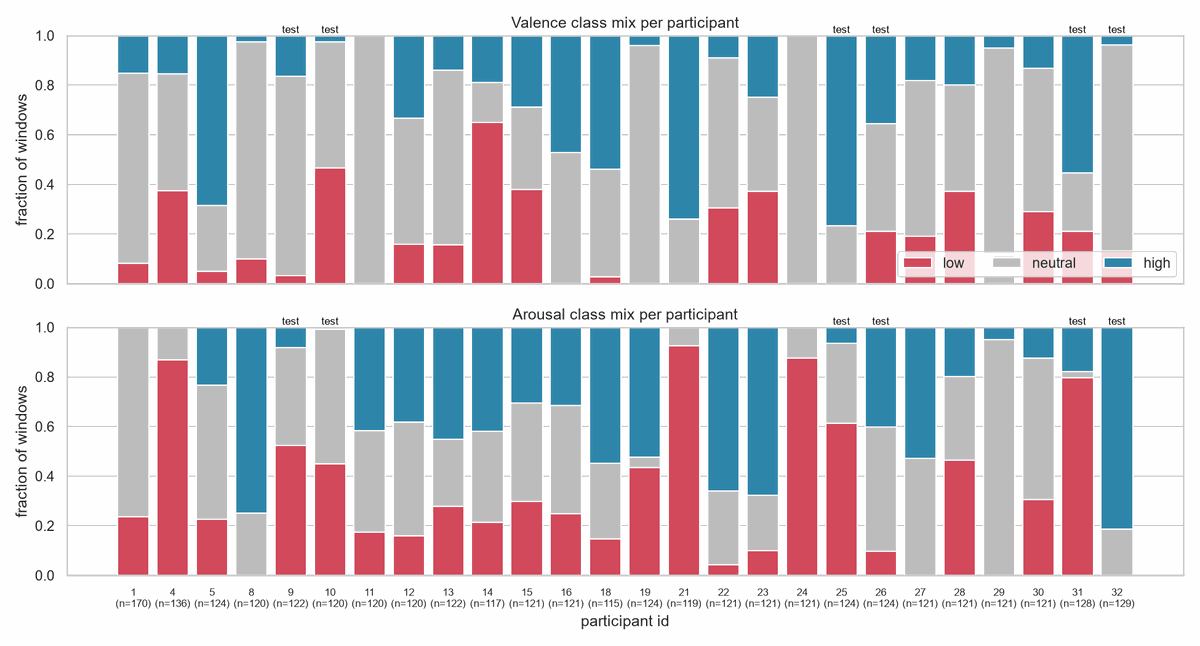

arousal : 37% of rating variance is explained by *which person* it is; 8 of 26 people put >=75% of their windows in a single class
valence : 24% of rating variance is explained by *which person* it is; 9 of 26 people put >=75% of their windows in a single class


In [7]:
show("data_labels_per_participant.png")
if HAVE_DATA:
    df = pd.read_csv(config.PROCESSED / "dataset.csv")
    for t in ["arousal", "valence"]:
        between = df.groupby("pid")[t].transform("mean").var() / df[t].var()
        top = df.groupby("pid")[f"{t}_cls"].agg(lambda s: s.value_counts(normalize=True).max())
        print(f"{t:8s}: {between:.0%} of rating variance is explained by *which person* it is; "
              f"{(top >= 0.75).sum()} of {len(top)} people put >=75% of their windows in a single class")

### 4.3 Body signals relate only weakly to the ratings
Even after removing person-to-person differences, no single feature correlates with the ratings by more than |ρ| ≈ 0.13. The strongest links are the textbook ones: **skin conductance, skin temperature and heart rate go up with arousal**. Valence has almost no physiological signature.

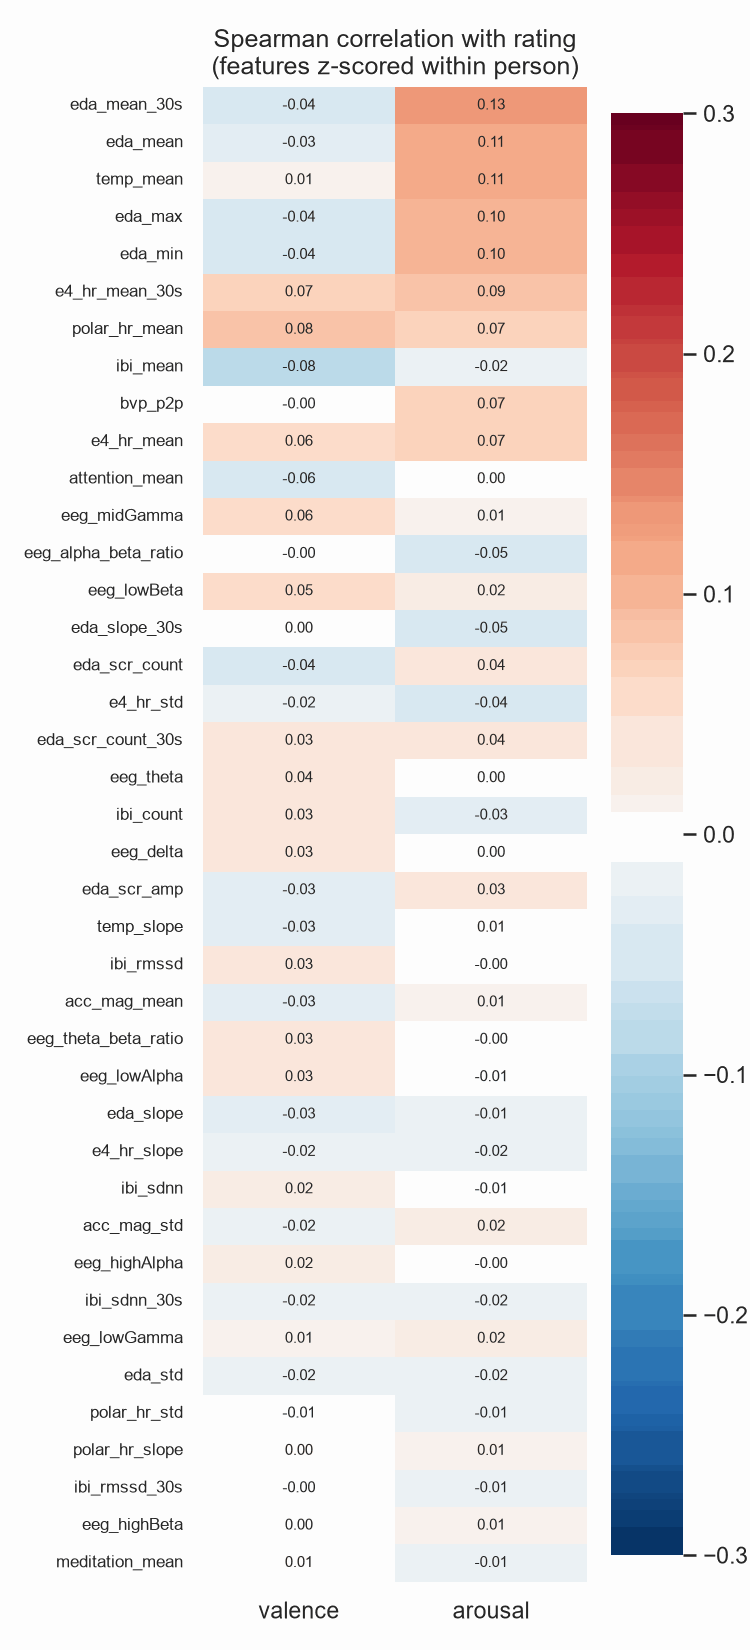

In [8]:
show("data_feature_label_correlation.png", width=420)

### 4.4 The relationship is slow (minutes), not instant (seconds)
Shifting the labels by up to ±2 minutes barely changes the correlation. The body-rating link is a slow trend. Ratings also stay constant for ~2 minutes on average, so second-by-second emotion tracking is not realistic with this data.

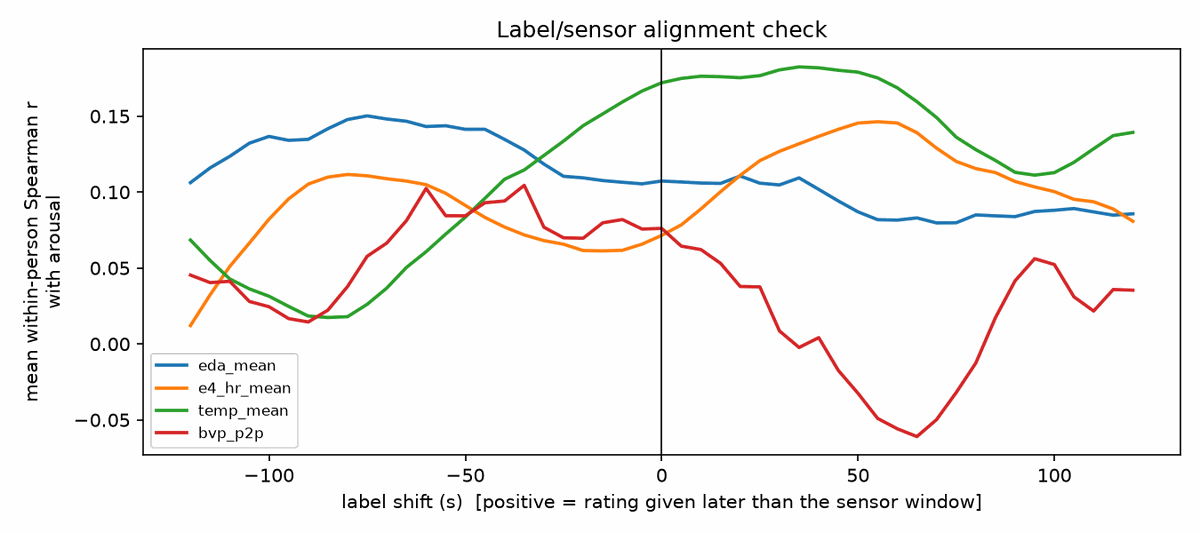

In [9]:
show("data_alignment_check.png", width=700)

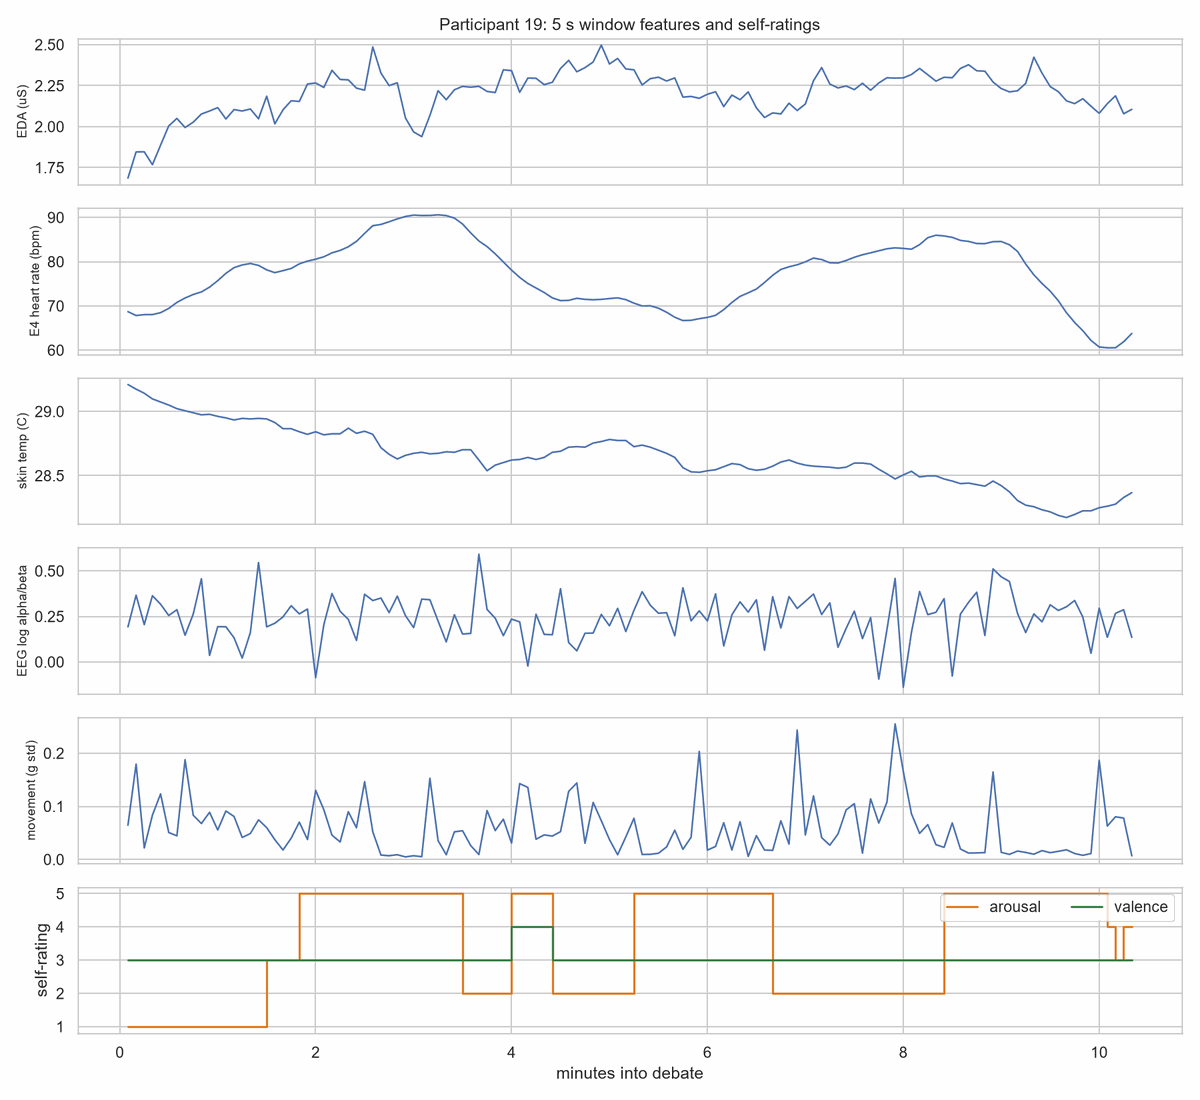

In [10]:
show("data_example_timeline.png", width=800)

## 5. Modelling: candidates, protocol, and why

**Task:** two separate classifiers, one for valence and one for arousal. Input: one 5 s window of features. Output: probabilities for low / neutral / high. **Confidence = the highest probability**; below a threshold the model answers *"unknown"*.

| Dimension | Options tried |
|---|---|
| Model | Logistic Regression (linear baseline), Random Forest, LightGBM (gradient boosting) |
| Sensors | **E4** only (25 features) · **E4+EEG** (35) · **ALL** (+ chest HR, NeuroSky attention/meditation; 40) |
| Per-person normalisation | none · pre-debate baseline · first 3 min of the conversation |
| Scenario | **Generic**: a new person, nothing known about them · **Personalised**: a 3-minute calibration at the start in which the person also rates themselves; their rating tendency is combined with the model: `p(class) ∝ p_model(class | sensors) × p_person(class)` |
| References | **Majority class** (always the most common answer) · **Prior only** (calibration ratings alone, no sensors), which shows whether the sensors add anything |

**Why tree models, not deep learning?**
- 20 training people is far too few for an LSTM or transformer on raw signals.
- Trees handle missing values and mixed scales.
- The FEEL benchmark (19 datasets) also finds hand-crafted features with Random Forests competitive.

**Protocol (why the numbers can be trusted):**
1. Model selection used **leave-one-debate-pair-out cross-validation inside the 20 training people**, so every validation prediction is on unseen people.
2. The best configuration per scenario was refitted on all training people and evaluated **once** on the **6 held-out test people**.
3. All scenarios are scored on the **same windows**: everything after each person's 3-minute calibration.
4. **Metrics:** accuracy; **macro-F1** (averages the three classes, so always guessing the common class scores low; chance ≈ 0.33); and for abstention, **coverage** (share of windows answered) vs. accuracy on them.

**Generic model, arousal: top 5 of 27 configurations (cross-validation)**

,feature_set,norm,model,accuracy,macro_f1,macro_f1_std_across_pairs
0,E4+EEG,none,random_forest,0.380,0.376,0.082
1,E4+EEG,calib,logreg,0.367,0.364,0.091
2,E4+EEG,none,lightgbm,0.363,0.361,0.103
3,ALL,none,random_forest,0.364,0.359,0.085
4,ALL,calib,logreg,0.361,0.358,0.088


**Generic model, valence: top 5 of 27 configurations (cross-validation)**

,feature_set,norm,model,accuracy,macro_f1,macro_f1_std_across_pairs
0,E4+EEG,none,random_forest,0.524,0.444,0.124
1,ALL,none,random_forest,0.521,0.437,0.116
2,E4,none,random_forest,0.517,0.436,0.135
3,ALL,none,lightgbm,0.502,0.410,0.117
4,E4,none,lightgbm,0.484,0.405,0.112


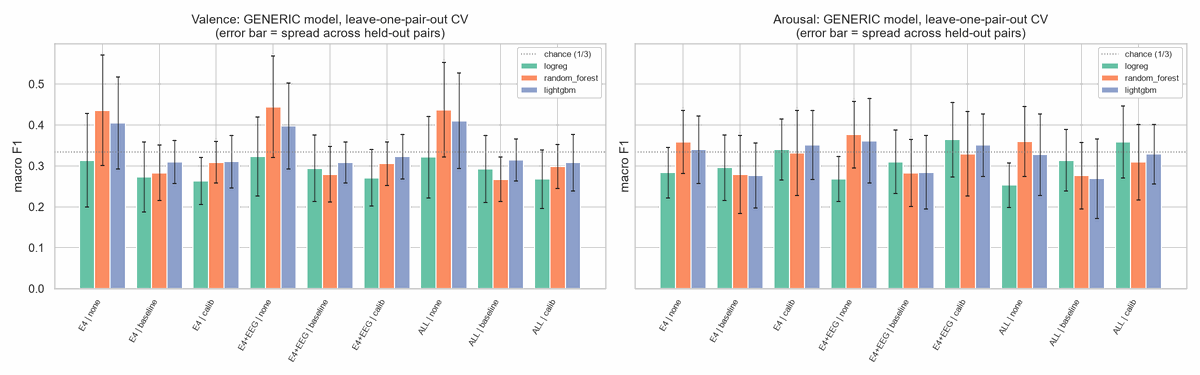

In [11]:
grid = pd.read_csv(APPROACH / "reports" / "cv_grid_generic.csv")
for t in ["arousal", "valence"]:
    g = grid[grid.target == t].sort_values("macro_f1", ascending=False).head(5)
    display(Markdown(f"**Generic model, {t}: top 5 of 27 configurations (cross-validation)**"))
    display(g[["feature_set", "norm", "model", "accuracy", "macro_f1", "macro_f1_std_across_pairs"]].reset_index(drop=True))
show("model_cv_generic_grid.png")

The error bars are large (±0.1–0.15 macro-F1 between held-out pairs). **How well the generic model does depends mostly on which people it is tested on**, which is a warning sign for generalisation.

## 6. Results

### 6.1 The four scenarios compared (after the 3-min calibration)

CV accuracy  CV macro-F1  \
target  approach                                                         
valence majority class                              0.578        0.244   
        prior only (calibration ratings)            0.539        0.442   
        generic (sensors)                           0.528        0.449   
        personalised (sensors + calibration)        0.577        0.476   
arousal majority class                              0.369        0.180   
        prior only (calibration ratings)            0.458        0.457   
        generic (sensors)                           0.417        0.409   
        personalised (sensors + calibration)        0.493        0.486   

                                              TEST accuracy  TEST macro-F1  
target  approach                                                            
valence majority class                                0.512            NaN  
        prior only (calibration ratings)              0.420          0.346  
        generic (sensors)                             0.169          0.124  
        personalised (sensors + calibration)          0.365          0.332  
arousal majority class                                0.328            NaN  
        prior only (calibration ratings)              0.486          0.487  
        generic (sensors)                             0.352          0.311  
        personalised (sensors + calibration)          0.597          0.587

chosen personalised arousal model: E4+EEG features, norm=none, random_forest
chosen personalised valence model: E4+EEG features, norm=none, logreg


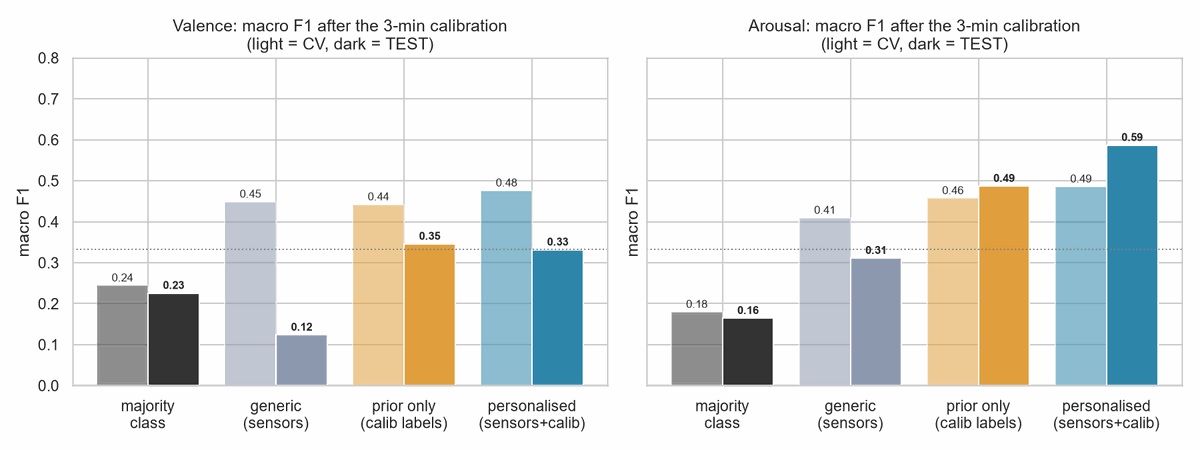

In [12]:
rows = []
for t, R in RES["targets"].items():
    ref = {"majority class": (R["cv_majority"], None), "prior only (calibration ratings)": (R["cv_prior_only"], R["test"]["prior_only"]["after_calibration"]),
           "generic (sensors)": (R["cv_best"]["generic"], R["test"]["generic"]["after_calibration"]),
           "personalised (sensors + calibration)": (R["cv_best"]["personalised"], R["test"]["personalised"]["after_calibration"])}
    for name, (cv, te) in ref.items():
        rows.append({"target": t, "approach": name, "CV accuracy": cv["accuracy"], "CV macro-F1": cv["macro_f1"],
                     "TEST accuracy": te["accuracy"] if te else R["test_majority_acc_after_calibration"],
                     "TEST macro-F1": te["macro_f1"] if te else np.nan})
display(pd.DataFrame(rows).set_index(["target", "approach"]))
for t in ["arousal", "valence"]:
    c = RES["targets"][t]["cv_best"]["personalised"]
    print(f"chosen personalised {t} model: {c['feature_set']} features, norm={c['norm']}, {c['model']}")
show("model_approach_comparison.png")

**Reading this:**
- **Generic models do not transfer to new people.** Valence even drops below chance on the test people.
- **Calibration fixes the rating-style problem.** For **arousal the sensors add real information on top**: 60% vs 49% for calibration alone, on the test people.
  - Example: test person P31 rated *high* during calibration, then *low* for the rest of the debate. Calibration alone gets 0% for them; the sensor model gets 60%.
- **Valence:** nothing beats the calibration ratings alone. Body signals carry no usable valence information here, consistent with the literature.

### 6.2 Where the arousal model makes mistakes

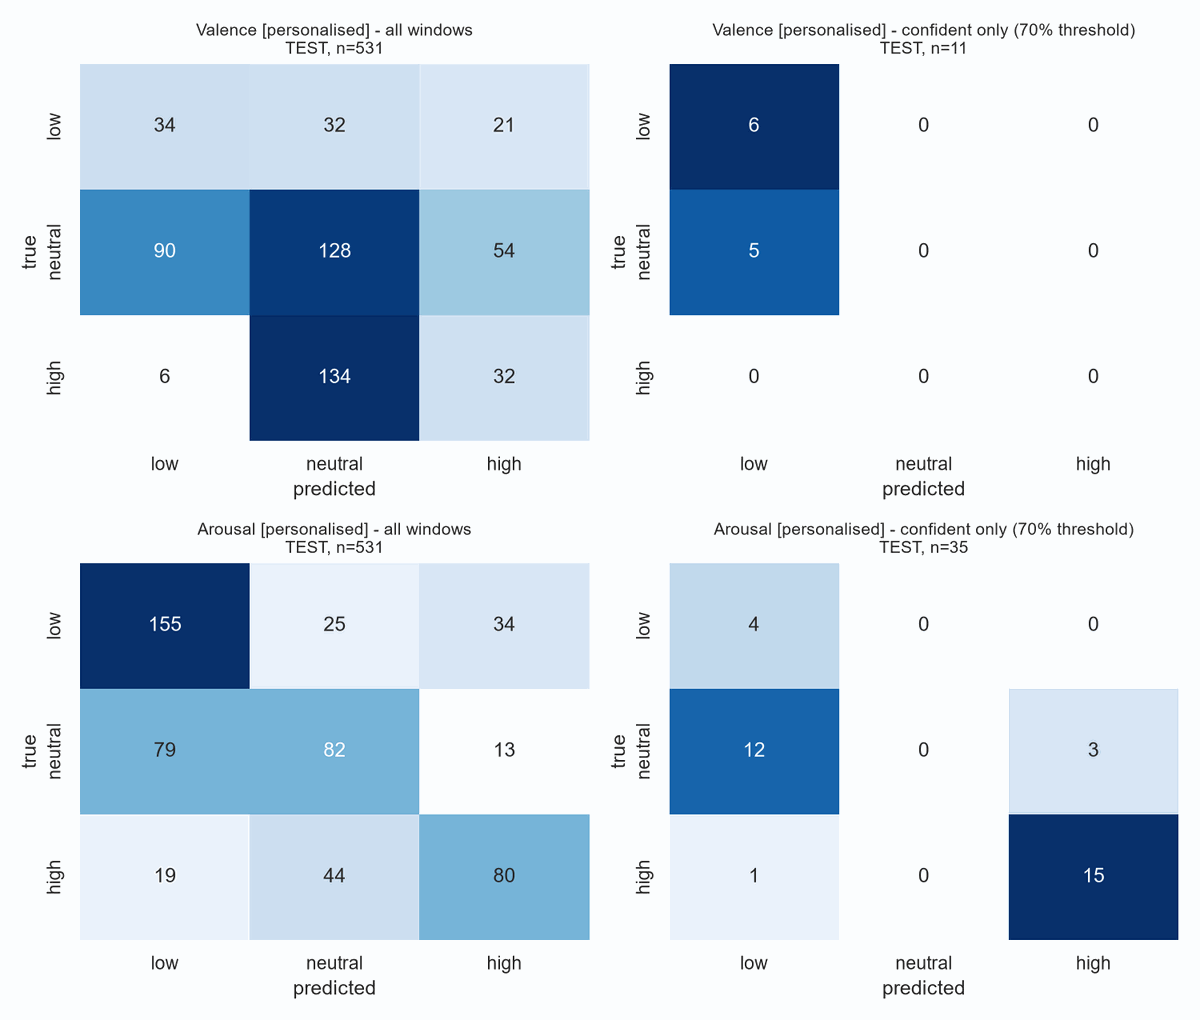

arousal: low<->high confusions = 53 of 531 windows (10%); most errors involve 'neutral'


In [13]:
show("model_confusion_test.png", width=750)
cm = np.array(RES["targets"]["arousal"]["test_confusion_all"])
print(f"arousal: low<->high confusions = {cm[0,2] + cm[2,0]} of {cm.sum()} windows ({(cm[0,2] + cm[2,0]) / cm.sum():.0%}); most errors involve 'neutral'")

### 6.3 Abstaining when unsure

The curve shows the accuracy on the windows the model answers (y) as it answers more of them (x), from most to least confident. A useful confidence score makes the curve **go up to the left**.

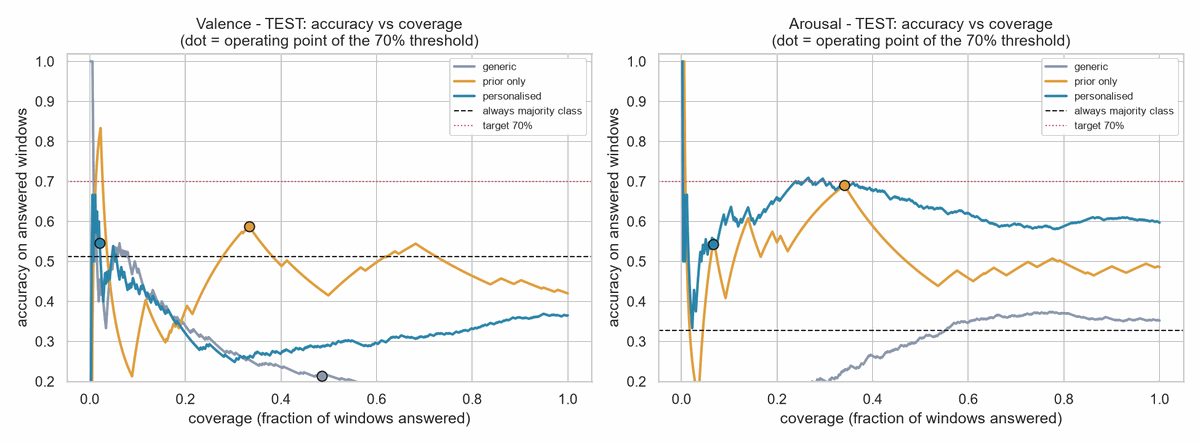

arousal: TEST accuracy on the most-confident 25% = 69%, 50% = 64%, all = 60%
valence: TEST accuracy on the most-confident 25% = 29%, 50% = 29%, all = 37%


confidence threshold  CV coverage  CV accuracy  \
target  threshold tuned for                                                   
arousal 60% acc                             0.720        0.426        0.600   
        70% acc                             0.806        0.285        0.700   
        80% acc                             0.867        0.168        0.800   
valence 60% acc                             0.586        0.831        0.600   
        70% acc                             0.913        0.358        0.701   
        80% acc                               NaN          NaN          NaN   

                             TEST coverage  TEST accuracy  
target  threshold tuned for                                
arousal 60% acc                      0.281          0.691  
        70% acc                      0.066          0.543  
        80% acc                      0.000            NaN  
valence 60% acc                      0.684          0.309  
        70% acc                      0.021          0.545  
        80% acc                        NaN            NaN

In [14]:
show("model_risk_coverage_test.png")
out = []
for t in ["arousal", "valence"]:
    d = RES["targets"][t]["test"]["personalised"]
    for tgt in ["0.6", "0.7", "0.8"]:
        cv, te = d["cv_selective_after_calibration"][tgt], d["selective_after_calibration"][tgt]
        out.append({"target": t, "threshold tuned for": f"{float(tgt):.0%} acc", "confidence threshold": d["thresholds"][tgt],
                    "CV coverage": cv["coverage"] if cv else None, "CV accuracy": cv["accuracy"] if cv else None,
                    "TEST coverage": te["coverage"] if te else None, "TEST accuracy": te["accuracy"] if te else None})
    a = d["after_calibration"]
    print(f"{t}: TEST accuracy on the most-confident 25% = {a['acc_at_25pct']:.0%}, 50% = {a['acc_at_50pct']:.0%}, all = {a['accuracy']:.0%}")
display(pd.DataFrame(out).set_index(["target", "threshold tuned for"]))

- **Arousal: the confidence ranking works on new people.** The top 25% most-confident windows are 69% correct vs 60% overall. The **60%-target threshold (p ≥ 0.72)** gave **69% accuracy on 28% of windows** on test.
- **But absolute thresholds shift between groups of people.** The 70% threshold tuned in CV answered only 7% of test windows, at 54%. The reliability plot below shows why: with only 20 training people, the probabilities are not calibrated.
  - Better for the live system: abstain by **rank within the session** ("answer only if this window is among the person's most confident so far") plus **temporal smoothing**.
- **Valence:** confidence has no relationship with correctness.

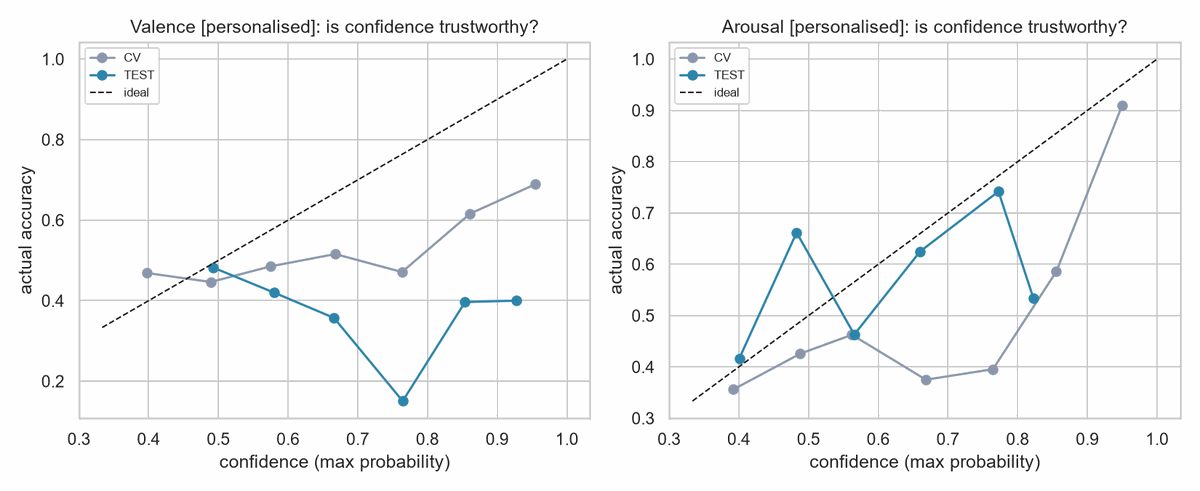

In [15]:
show("model_reliability.png", width=800)

### 6.4 What the arousal model looks at

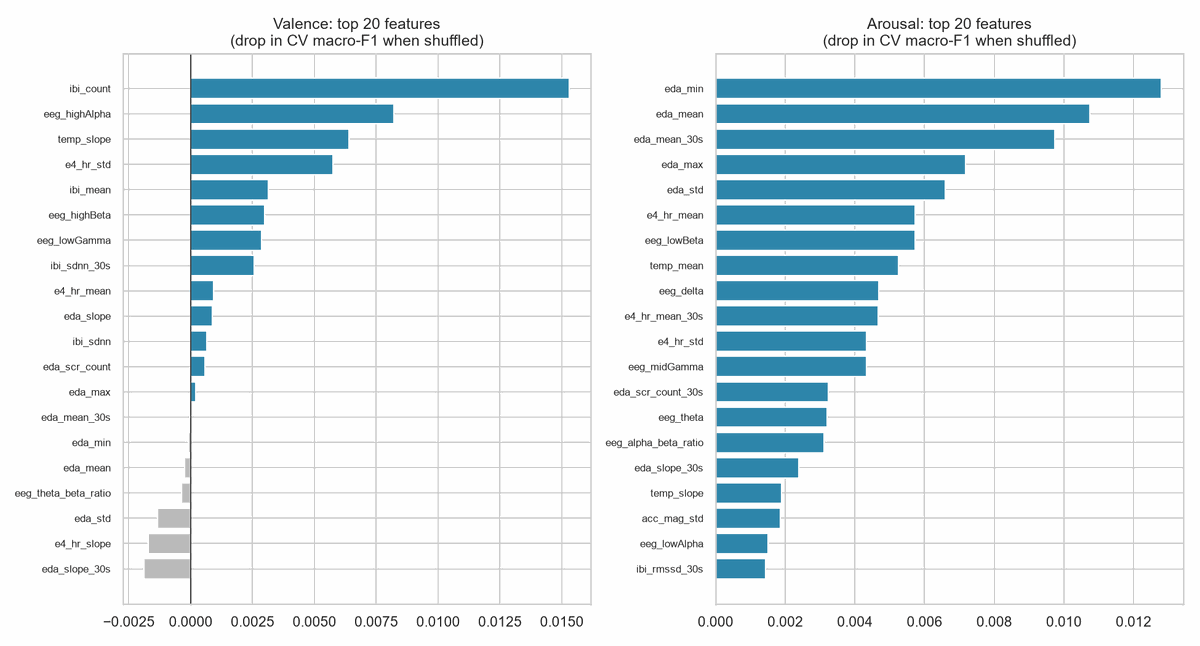

arousal top 8: eda_min, eda_mean, eda_mean_30s, eda_max, eda_std, e4_hr_mean, eeg_lowBeta, temp_mean


In [16]:
show("model_feature_importance.png")
imp = pd.Series(RES["targets"]["arousal"]["permutation_importance"]).sort_values(ascending=False)
print("arousal top 8:", ", ".join(imp.index[:8]))

The top five arousal features are all **skin-conductance** features, followed by heart rate, EEG beta and skin temperature. This is the textbook physiology of arousal, which is good evidence the model learned something real. The chest strap and NeuroSky attention/meditation never helped: **E4 + EEG** was the best sensor set.

### 6.5 Per person, over time

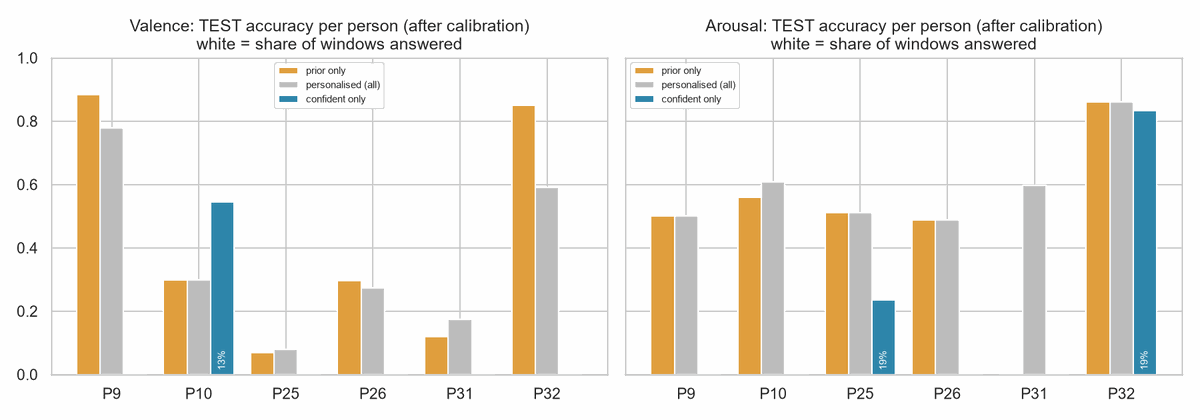

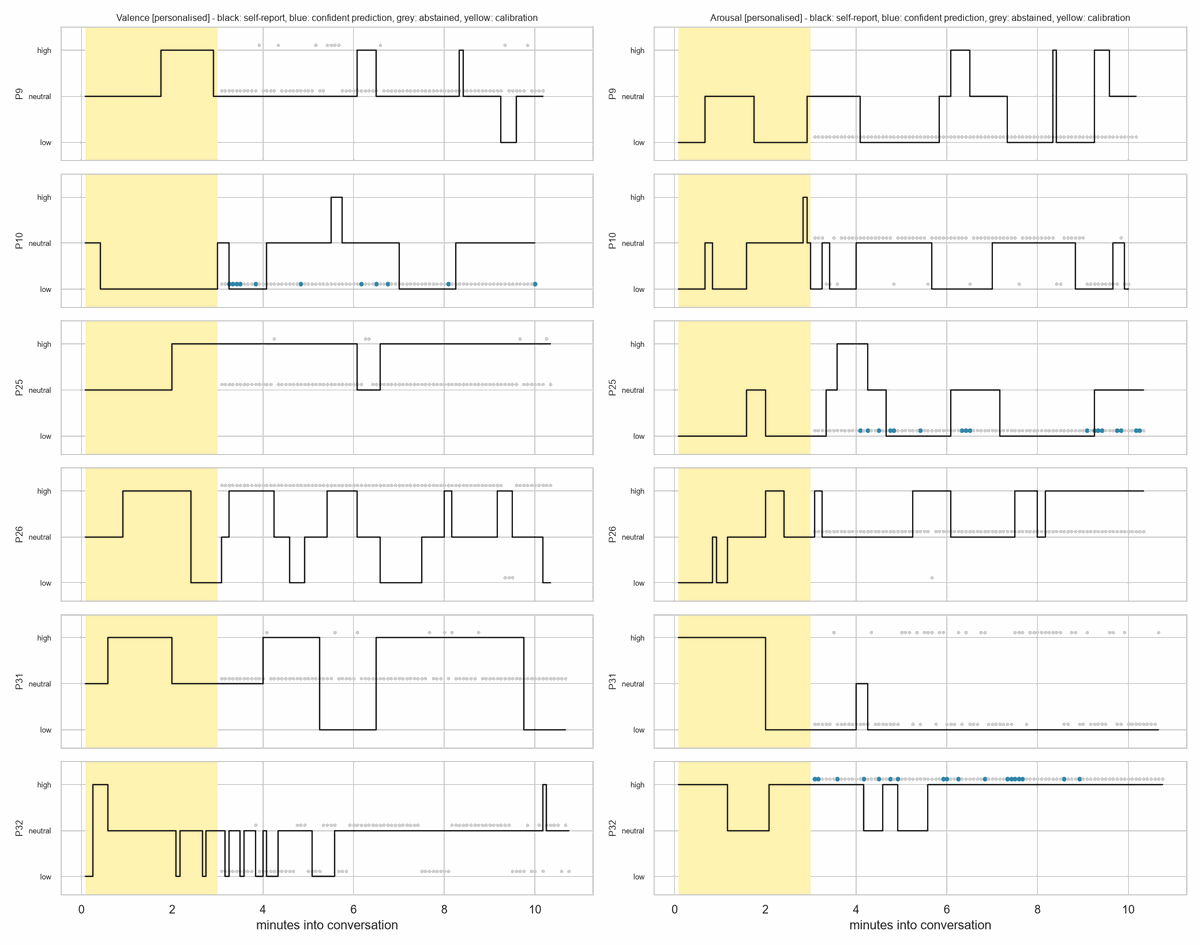

In [17]:
show("model_test_per_participant.png"); show("model_test_timelines.png", width=1000)

Black = self-rating, blue = confident prediction, grey = abstained, yellow = calibration.

**Honest limitation:** within a person, the arousal prediction is fairly **flat**. It identifies the person's *current overall level* (calm / neutral / activated) rather than following every change minute by minute. That matches §4.3–4.4: the body-rating link is weak and slow.

## 7. Why published papers report 90%+ on the *same* dataset

| Paper | Reported | What's behind it |
|---|---|---|
| **Zitouni et al.**, IEEE JBHI 2023 (BiLSTM, HR + EDA + temperature) | ~95–97% valence and arousal | (1) **2 classes, with rating 3 counted as "high"**. (2) **Same people in train and test** (4-fold CV over pooled, overlapping windows). (3) Temporal smoothing applied to predictions **and ground truth**. (4) Best numbers use partner ratings. **Their own new-person test (leave-one-subject-out): arousal 67.9%, valence 76.0%** |
| **HGR-RFAF**, Eng. Appl. of AI 2025 (CNN + attention) | 91% arousal / 93% valence | Full text paywalled; the abstract does not claim new-person testing; no code |

The cell below computes what "always say *high*" scores under Zitouni's 2-class rule on our data:

In [18]:
if HAVE_DATA:
    for t, theirs in [("arousal", 67.9), ("valence", 76.0)]:
        base = np.mean(df[t] >= 3) * 100
        verdict = "below" if theirs < base - 1 else "about the same as"
        print(f"{t}: always predicting 'high' (rating >= 3) is correct {base:.1f}% of the time "
              f"-> Zitouni's new-person result ({theirs}%) is {verdict} this trivial baseline")

arousal: always predicting 'high' (rating >= 3) is correct 67.2% of the time -> Zitouni's new-person result (67.9%) is about the same as this trivial baseline
valence: always predicting 'high' (rating >= 3) is correct 82.6% of the time -> Zitouni's new-person result (76.0%) is below this trivial baseline


**So the gap is the evaluation, not the model.** When tested the way the chatbot will actually be used (new people, 3 classes, no label smoothing), even the best published model does no better than a trivial baseline. Our personalised arousal model is.

## 8. Conclusions and next direction

**What we established**
1. A full, documented pipeline: raw K-EmoCon → 3,223 windows × 40 features → person-level split → honest evaluation.
2. **Arousal is partially predictable from body sensors**, mainly skin conductance, *after* a short per-person calibration. It reaches 60% on 3 classes, 69% when answering only confident windows.
3. **Valence is not predictable from body sensors** in this data.
4. **The main obstacle is person-to-person differences** (rating style, physiology), not the choice of model. With ~20 training people, no model generalises to a stranger without calibration. This also explains the 90%+ claims in the literature.

**Why the next step will probably *not* be "train a bigger emotion classifier"**
- More model capacity does not fix person differences or retrospective, sticky, mostly-neutral labels.
- The confidence of a learned classifier is not reliable across people, but our requirement is precisely *"no answer rather than a wrong one"*.
- Valence is carried by **language and voice**, not the body.

**Proposed direction** (to be decided):
- **Body sensors → interpretable, measured descriptors, no black-box model.**
  - E.g. *"activation elevated vs. this person's own baseline, rising for 40 s; 3 stress responses in the last minute"*.
  - These are personal by design, need no training labels, and their confidence comes from signal quality.
- **Events:** tag the chatbot message after which a skin-conductance or heart-rate reaction occurred.
- **Valence from the conversation text** (the LLM already sees it) and, optionally, voice.
- **The LLM fuses** these descriptors with the conversation into the emotional-state summary stored in its memory.
- **Collect our own lab data** with in-the-moment ratings to validate whatever we build.

## 9. How to reproduce

```bash
cd approaches/kemocon_physio_ml
python -m venv .venv && .venv/Scripts/pip install -r requirements.txt
# request K-EmoCon and extract it into data/raw/  (see data/README.md)
cd src
../.venv/Scripts/python build_dataset.py
../.venv/Scripts/python explore_dataset.py
../.venv/Scripts/python check_alignment.py
../.venv/Scripts/python train.py --regrid      # ~25 min
```
This notebook reads the results from `reports/`. The cells that need the raw data are skipped automatically when `data/` is absent.